# Load


## Imports and Setup

In [15]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, BoundaryNorm, ListedColormap
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import csv
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry import LineString
import shapely.wkt
import movingpandas as mpd
from shapely.geometry import Point
from datetime import timedelta
import trackintel as ti
import glob

In [16]:
FOOT_CYCLE_ONLY = {
    "track",
    "path",
    "cycleway",
    "footway"
}
MASK = gpd.read_file("Data/Banks_Mask_Buffered.gpkg").to_crs(epsg=2193)

def check_highway_match(highway_value):
    if isinstance(highway_value, str):
        # Try to parse string representation of list
        if highway_value.startswith('['):
            import ast
            try:
                highway_list = ast.literal_eval(highway_value)
            except:
                highway_list = [highway_value]
        else:
            highway_list = [highway_value]
    elif isinstance(highway_value, list):
        highway_list = highway_value
    else:
        highway_list = [highway_value]
    
    return bool(set(highway_list) & FOOT_CYCLE_ONLY)

## Data Sources

In [31]:
Mobile_activities = gpd.read_file("Data/Mobile/Joined/joined_matched_edges.gpkg")

Mobile_trajectories = pd.read_csv("Data/Mobile/Trajectories/trajectories.csv")

Wikiloc_activities = gpd.read_file("Data/Wikiloc/Joined/joined_matched_edges.gpkg")

Alltrail_counts = gpd.read_file("Data/Alltrails/Joined/joined_matched_edges.gpkg")
Alltrail_activities = pd.read_csv("Data/Alltrails/Downloads/activity_index.csv")

Strava_activities = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_counts_with_edge_ids.csv")

Counter_Locations = gpd.read_file("Data/DOC_Counter_Locations.gpkg")
Counter_data = pd.read_csv("Data/DOC_Counter_Data_Full.csv")
Edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp")




C:\Users\maxwe\AppData\Local\Temp\ipykernel_6092\2142775619.py:10: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  Strava_activities = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_counts_with_edge_ids.csv")


In [32]:
try:
    Edges = Edges.to_crs(epsg=2193)
except Exception:
    pass

# Create edges_filtered by keeping only foot/cycle highways using the helper
# (check_highway_match is defined earlier in the notebook)
edges_filtered = Edges[Edges['highway'].apply(check_highway_match)].copy()

# Ensure filtered edges use the target CRS and optionally clip to the MASK
try:
    edges_filtered = edges_filtered.to_crs(epsg=2193)
except Exception:
    pass

# Report basic summary
print(f'edges_filtered: {len(edges_filtered)} features — CRS: {getattr(edges_filtered, "crs", None)}')

edges_filtered: 9360 features — CRS: EPSG:2193


# Plotting

## Timeline

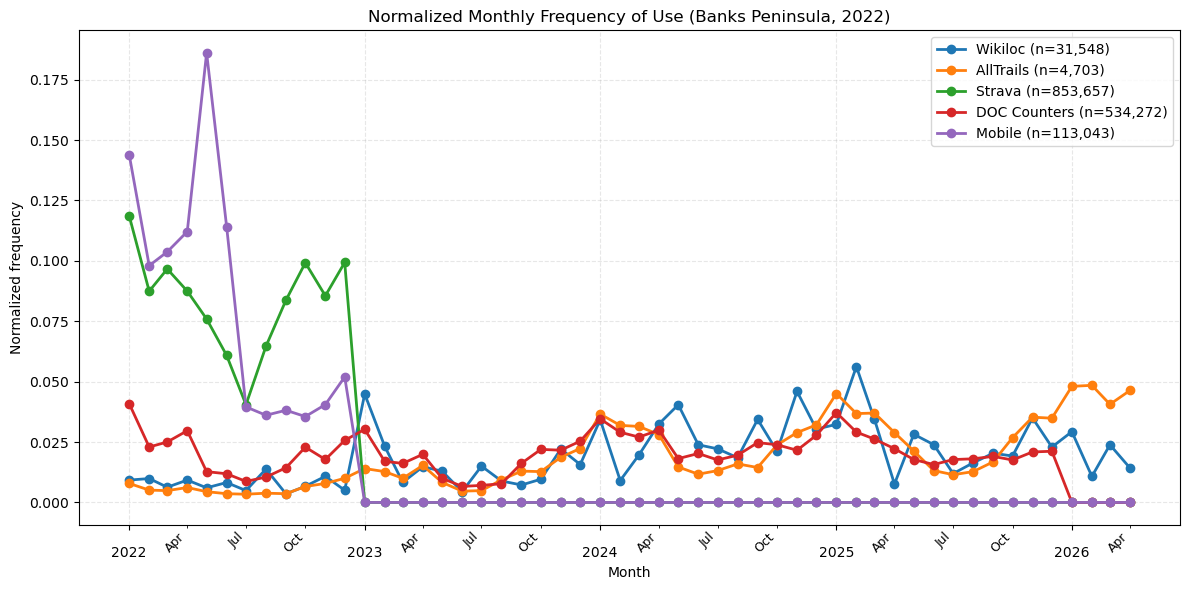

In [33]:
# Build a monthly index for the full analysis period
months_2022 = pd.date_range("2022-01-01", "2026-04-01", freq="MS")

# Parse and clean dates from the current source columns
wikiloc_dates = pd.to_datetime(Wikiloc_activities["start_time"], errors="coerce")
alltrails_dates = pd.to_datetime(Alltrail_activities["activity_date"], errors="coerce", dayfirst=True)
strava_dates = pd.to_datetime(Strava_activities["time"], errors="coerce")
counter_dates = pd.to_datetime(Counter_data["Datetime"], errors="coerce")
mobile_dates = pd.to_datetime(Mobile_trajectories["start_time"], errors="coerce")

# Remove implausible historical timestamps that come from parser/source artifacts
wikiloc_dates = wikiloc_dates[wikiloc_dates.dt.year >= 2000]
alltrails_dates = alltrails_dates[alltrails_dates.dt.year >= 2000]
strava_dates = strava_dates[strava_dates.dt.year >= 2000]
counter_dates = counter_dates[counter_dates.dt.year >= 2000]
mobile_dates = mobile_dates[mobile_dates.dt.year >= 2000]

# Wikiloc: count trajectories by start month
wikiloc_monthly = (
    pd.Series(1, index=wikiloc_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# AllTrails: count activities by activity_date month
alltrails_monthly = (
    pd.Series(1, index=alltrails_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# Strava: count activities by time month
strava_monthly = (
    pd.Series(1, index=strava_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# DOC counters: sum hourly counts into monthly totals
doc_monthly = (
    Counter_data.assign(Datetime=counter_dates)
    .dropna(subset=["Datetime"])
    .set_index("Datetime")["Count"]
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# Mobile: count trajectories by start_time month
mobile_monthly = (
    pd.Series(1, index=mobile_dates)
    .groupby(pd.Grouper(freq="MS"))
    .sum()
    .reindex(months_2022, fill_value=0)
)

# Normalize each source to relative monthly frequency (sum of each line = 1)
def normalize_series(series):
    total = series.sum()
    return series / total if total > 0 else series

wikiloc_norm = normalize_series(wikiloc_monthly)
alltrails_norm = normalize_series(alltrails_monthly)
strava_norm = normalize_series(strava_monthly)
doc_norm = normalize_series(doc_monthly)
mobile_norm = normalize_series(mobile_monthly)

wikiloc_total = int(wikiloc_monthly.sum())
alltrails_total = int(alltrails_monthly.sum())
strava_total = int(strava_monthly.sum())
doc_total = int(doc_monthly.sum())
mobile_total = int(mobile_monthly.sum())

# Plot 1: overlayed monthly normalized frequencies with totals in legend (2022)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(months_2022, wikiloc_norm.values, marker="o", linewidth=2, label=f"Wikiloc (n={wikiloc_total:,})")
ax.plot(months_2022, alltrails_norm.values, marker="o", linewidth=2, label=f"AllTrails (n={alltrails_total:,})")
ax.plot(months_2022, strava_norm.values, marker="o", linewidth=2, label=f"Strava (n={strava_total:,})")
ax.plot(months_2022, doc_norm.values, marker="o", linewidth=2, label=f"DOC Counters (n={doc_total:,})")
ax.plot(months_2022, mobile_norm.values, marker="o", linewidth=2, label=f"Mobile (n={mobile_total:,})")

ax.set_title("Normalized Monthly Frequency of Use (Banks Peninsula, 2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")

year_ticks = pd.date_range(months_2022.min(), months_2022.max(), freq="YS")
quarter_ticks = months_2022[::3]
ax.set_xticks(year_ticks)
ax.set_xticklabels([d.strftime("%Y") for d in year_ticks])
ax.set_xticks(quarter_ticks, minor=True)
ax.set_xticklabels([d.strftime("%b") for d in quarter_ticks], minor=True, rotation=45, ha="right")
ax.tick_params(axis="x", which="major", pad=12)
ax.tick_params(axis="x", which="minor", pad=2, labelsize=9)

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



In [20]:
# # Plot 5: Aggregate all years into a single normalized Jan-Dec profile
# # Example: all January observations from all years are summed into January.

month_numbers = pd.Index(range(1, 13), name="month")
month_labels = [pd.Timestamp(2000, month, 1).strftime("%b") for month in month_numbers]

In [21]:
def plot_edge_heatmap(edge_counts, title, cmap, legend_label, debug=False):
    import matplotlib as mpl
    import matplotlib.patches as mpatches

    edges_with_counts = edges_filtered.copy()
    edges_with_counts["activity_count"] = edges_with_counts.index.map(edge_counts)
    active_edges = edges_with_counts[edges_with_counts["activity_count"] > 0]
    inactive_edges = edges_with_counts[edges_with_counts["activity_count"] == 0]

    fig, ax = plt.subplots(figsize=(14, 12))

    MASK.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=0)

    if len(inactive_edges) > 0:
        inactive_edges.plot(ax=ax, linewidth=0.5, color="lightgrey", alpha=0.3, zorder=1)

    if len(active_edges) > 0:
        counts = active_edges["activity_count"].astype(float)
        n = len(counts)

        if debug:
            print("DEBUG: active_edges count=", n)
            print("DEBUG: counts min/max/unique:", counts.min(), counts.max(), counts.nunique())

        # Resolve colormap parameter (accept name or colormap object)
        try:
            if isinstance(cmap, str):
                cmap_obj = plt.get_cmap(cmap)
            else:
                cmap_obj = cmap
        except Exception:
            cmap_obj = plt.get_cmap('viridis')

        # If all counts identical, plot single saturated colour from the chosen cmap
        if counts.nunique() == 1:
            color = cmap_obj(0.6)
            active_edges.plot(ax=ax, color=[mpl.colors.to_hex(color)] * len(active_edges), linewidth=2.6, alpha=1.0, zorder=3)
            ax.set_title(f"{title} — all edges = {int(counts.iloc[0]):,}", fontsize=14)
            if debug:
                print("DEBUG: all counts identical -> single colour used")
        else:
            # Number of bins (deciles) - no more than number of edges
            n_bins = min(10, n)

            # Rank-based bin assignment to ensure ~equal number of edges per bin
            ranks = counts.rank(method='first').astype(int)
            bin_idx = ((ranks - 1) * n_bins) // n
            bin_idx = bin_idx.astype(int)

            if debug:
                print("DEBUG: n_bins=", n_bins)
                print("DEBUG: bin_idx value_counts:\n", bin_idx.value_counts().sort_index())

            # Sample n_bins colours linearly from the chosen colormap
            palette = cmap_obj(np.linspace(0.05, 0.95, n_bins))

            patches = []
            # Plot each bin with a white halo under the colour to make it visible over background
            for i in range(n_bins):
                idx = bin_idx[bin_idx == i].index
                if len(idx) == 0:
                    continue
                group = active_edges.loc[idx]

                halo_width = 3.6  # white halo width
                col_width = 2.2   # coloured line width
                halo_col = '#ffffff'
                colour = mpl.colors.to_hex(palette[i])

                # white halo (draw first)
                group.plot(ax=ax, color=halo_col, linewidth=halo_width, alpha=1.0, zorder=2)
                # coloured line on top
                group.plot(ax=ax, color=colour, linewidth=col_width, alpha=1.0, zorder=3)

                # legend label for this bin using actual min/max in the bin
                group_counts = counts.loc[idx]
                lower = int(group_counts.min())
                upper = int(group_counts.max())
                label = f"{lower:,}–{upper:,} ({len(idx)} edges)"
                patches.append(mpatches.Patch(color=colour, label=label))

            if patches:
                ax.legend(handles=patches, title=legend_label, loc="lower left", fontsize=9)

            if debug:
                # show sample palette hex codes
                print("DEBUG: palette hex:", [mpl.colors.to_hex(c) for c in palette])

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

## Month-of-Year Profiles and Heatmap Helpers

In [34]:
# Aggregate all years into a single Jan-Dec profile and normalise
def month_profile(monthly_series):
    by_month = monthly_series.groupby(monthly_series.index.month).sum().reindex(range(1, 13), fill_value=0)
    total = by_month.sum()
    norm = by_month / total if total > 0 else by_month.astype(float)
    norm_roll3 = norm.rolling(3, center=True, min_periods=1).mean()
    return by_month, norm, norm_roll3

wikiloc_by_month_all_years, wikiloc_by_month_norm, wikiloc_by_month_norm_roll3 = month_profile(wikiloc_monthly)
alltrails_by_month_all_years, alltrails_by_month_norm, alltrails_by_month_norm_roll3 = month_profile(alltrails_monthly)
strava_by_month_all_years, strava_by_month_norm, strava_by_month_norm_roll3 = month_profile(strava_monthly)
doc_by_month_all_years, doc_by_month_norm, doc_by_month_norm_roll3 = month_profile(doc_monthly)
mobile_by_month_all_years, mobile_by_month_norm, mobile_by_month_norm_roll3 = month_profile(mobile_monthly)


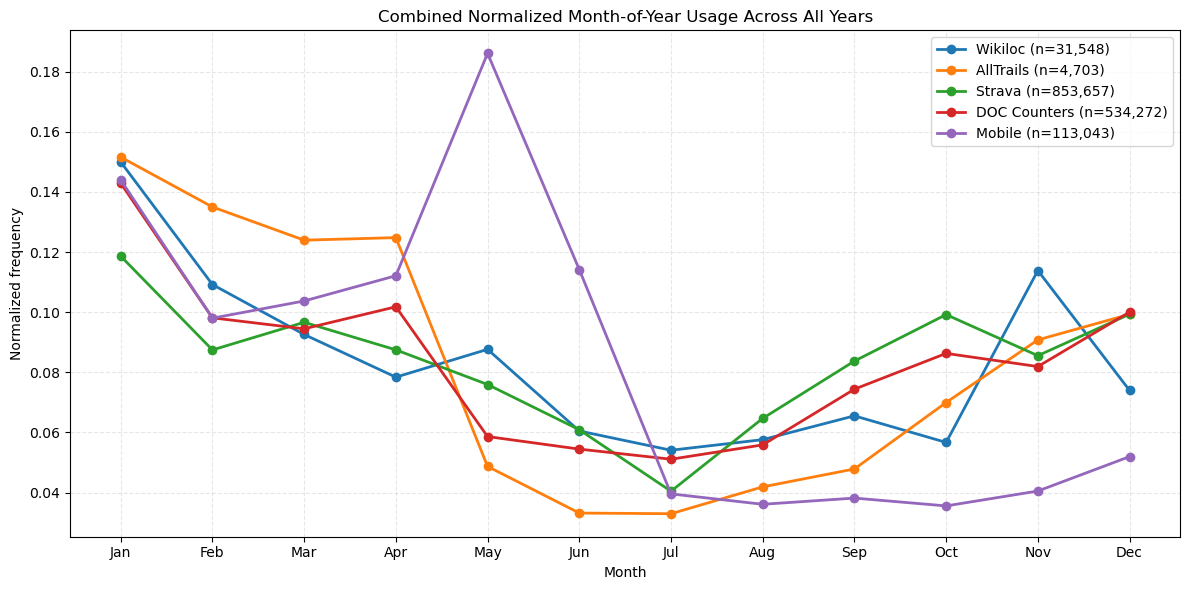

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_by_month_all_years.sum()):,})")
ax.plot(month_labels, alltrails_by_month_norm.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_by_month_all_years.sum()):,})")
ax.plot(month_labels, strava_by_month_norm.values, marker="o", linewidth=2, label=f"Strava (n={int(strava_by_month_all_years.sum()):,})")
ax.plot(month_labels, doc_by_month_norm.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_by_month_all_years.sum()):,})")
ax.plot(month_labels, mobile_by_month_norm.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_by_month_all_years.sum()):,})")

ax.set_title("Combined Normalized Month-of-Year Usage Across All Years")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


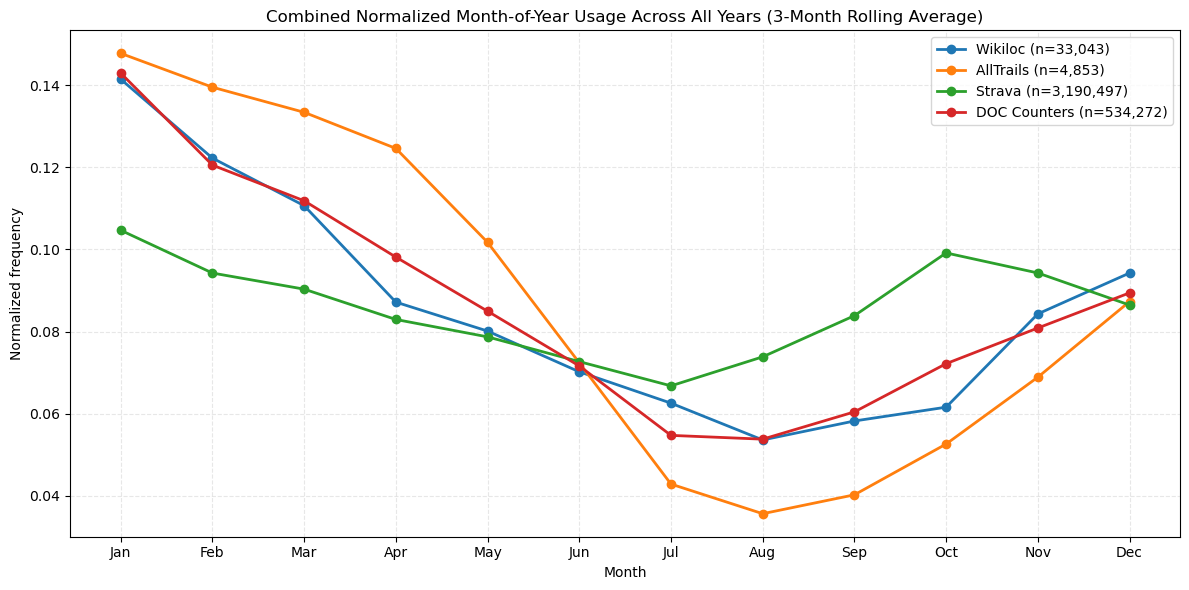

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"Wikiloc (n={int(wikiloc_by_month_all_years.sum()):,})")
ax.plot(month_labels, alltrails_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"AllTrails (n={int(alltrails_by_month_all_years.sum()):,})")
ax.plot(month_labels, strava_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"Strava (n={int(strava_by_month_all_years.sum()):,})")
ax.plot(month_labels, doc_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"DOC Counters (n={int(doc_by_month_all_years.sum()):,})")
# ax.plot(month_labels, mobile_by_month_norm_roll3.values, marker="o", linewidth=2, label=f"Mobile (n={int(mobile_by_month_all_years.sum()):,})")

ax.set_title("Combined Normalized Month-of-Year Usage Across All Years (3-Month Rolling Average)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Edge Heatmaps

C:\Users\maxwe\AppData\Local\Temp\ipykernel_6092\3399797377.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  source_counts = pd.read_csv(source_counts_path)


Saved strava edge trip counts to Data\Strava\strava_edge_trip_counts.gpkg


,edge_id,trip_count
3959,8185,200430
2448,5243,170760
56,379,151680
895,2197,148335
1624,3133,130630
5852,11173,87835
3958,8184,87390
5357,10479,83020
7068,12693,73585
1009,2360,72385


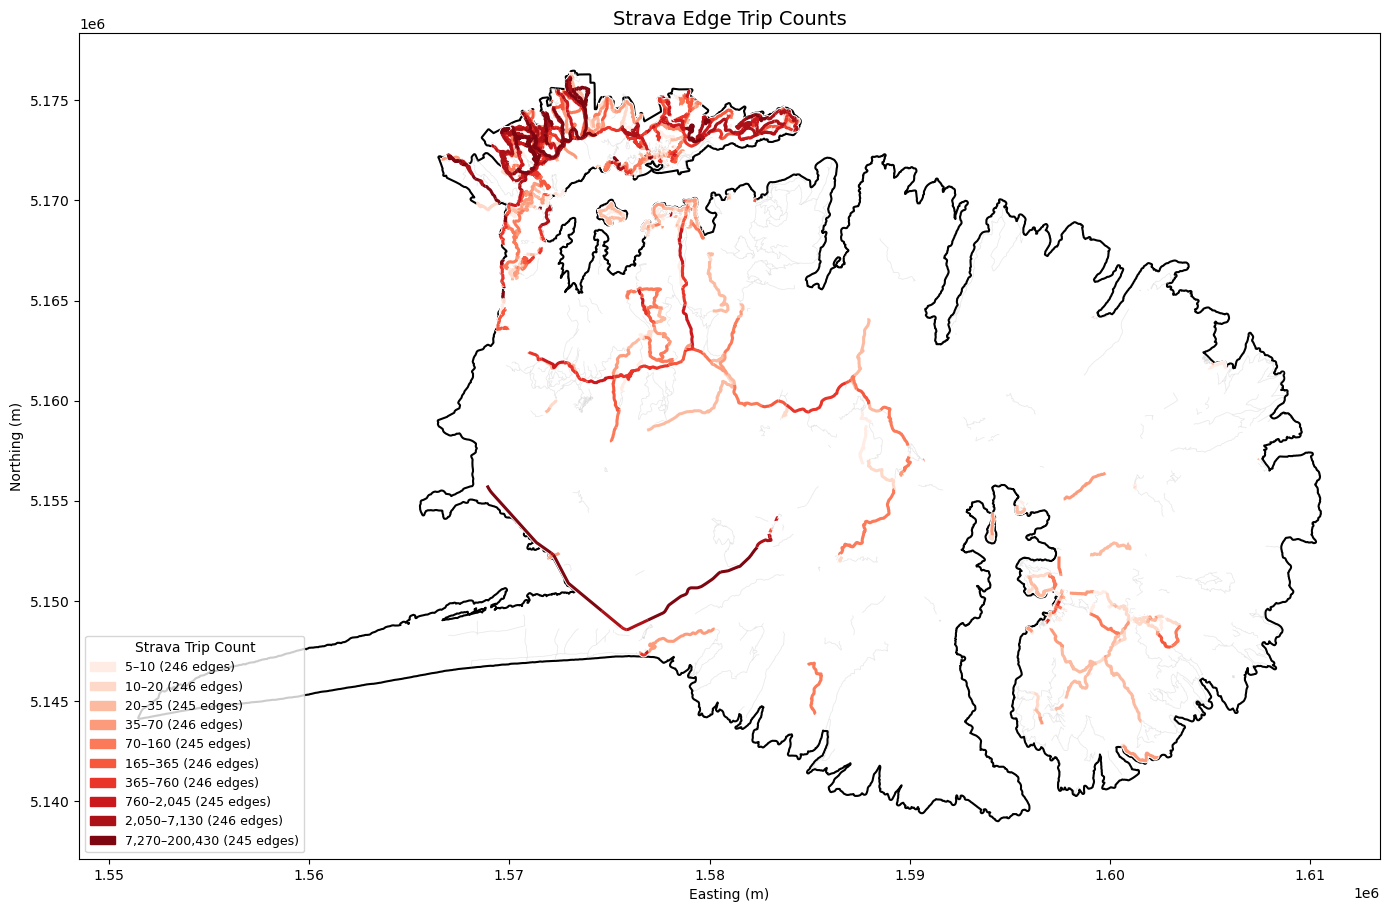

In [36]:
import os


def build_edge_trip_counts_layer(source_name, source_counts_path, output_path, count_column="total_trip_count"):
    source_counts = pd.read_csv(source_counts_path)
    if "edge_id" not in source_counts.columns:
        raise KeyError(f"{source_counts_path} does not contain an edge_id column")
    if count_column not in source_counts.columns:
        raise KeyError(f"{source_counts_path} does not contain a {count_column} column")

    counts = source_counts[["edge_id", count_column]].copy()
    counts["edge_id"] = pd.to_numeric(counts["edge_id"], errors="coerce")
    counts[count_column] = pd.to_numeric(counts[count_column], errors="coerce").fillna(0)
    counts = (
        counts.dropna(subset=["edge_id"])
        .groupby("edge_id", as_index=False)[count_column]
        .sum()
        .rename(columns={count_column: "trip_count"})
    )
    counts["edge_id"] = counts["edge_id"].astype(int)

    edge_base = edges_filtered.copy() if "edges_filtered" in globals() else edges.copy()
    if "edge_id" not in edge_base.columns:
        edge_base = edge_base.reset_index()
        if "edge_id" not in edge_base.columns and "index" in edge_base.columns:
            edge_base = edge_base.rename(columns={"index": "edge_id"})
    edge_base["edge_id"] = pd.to_numeric(edge_base["edge_id"], errors="coerce").astype("Int64")

    edge_trip_counts = edge_base.merge(counts, on="edge_id", how="left")
    edge_trip_counts["trip_count"] = edge_trip_counts["trip_count"].fillna(0).astype(int)
    edge_trip_counts["source"] = source_name

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    edge_trip_counts.to_file(output_path, driver="GPKG")
    print(f"Saved {source_name} edge trip counts to {output_path}")

    return edge_trip_counts, edge_trip_counts.set_index("edge_id")["trip_count"].to_dict()


strava_edge_trip_counts_path = os.path.join("Data", "Strava", "strava_edge_trip_counts.gpkg")
strava_counts_path = os.path.join("Data", "Strava", "strava_2022_bankspeninsula_counts_with_edge_ids.csv")

strava_edge_trip_counts, strava_edge_counts = build_edge_trip_counts_layer(
    "strava",
    strava_counts_path,
    strava_edge_trip_counts_path,
)

display(
    strava_edge_trip_counts[["edge_id", "trip_count"]]
    .sort_values("trip_count", ascending=False)
    .head(10)
)

plot_edge_heatmap(
    strava_edge_counts,
    "Strava Edge Trip Counts",
    "Reds",
    "Strava Trip Count",
)


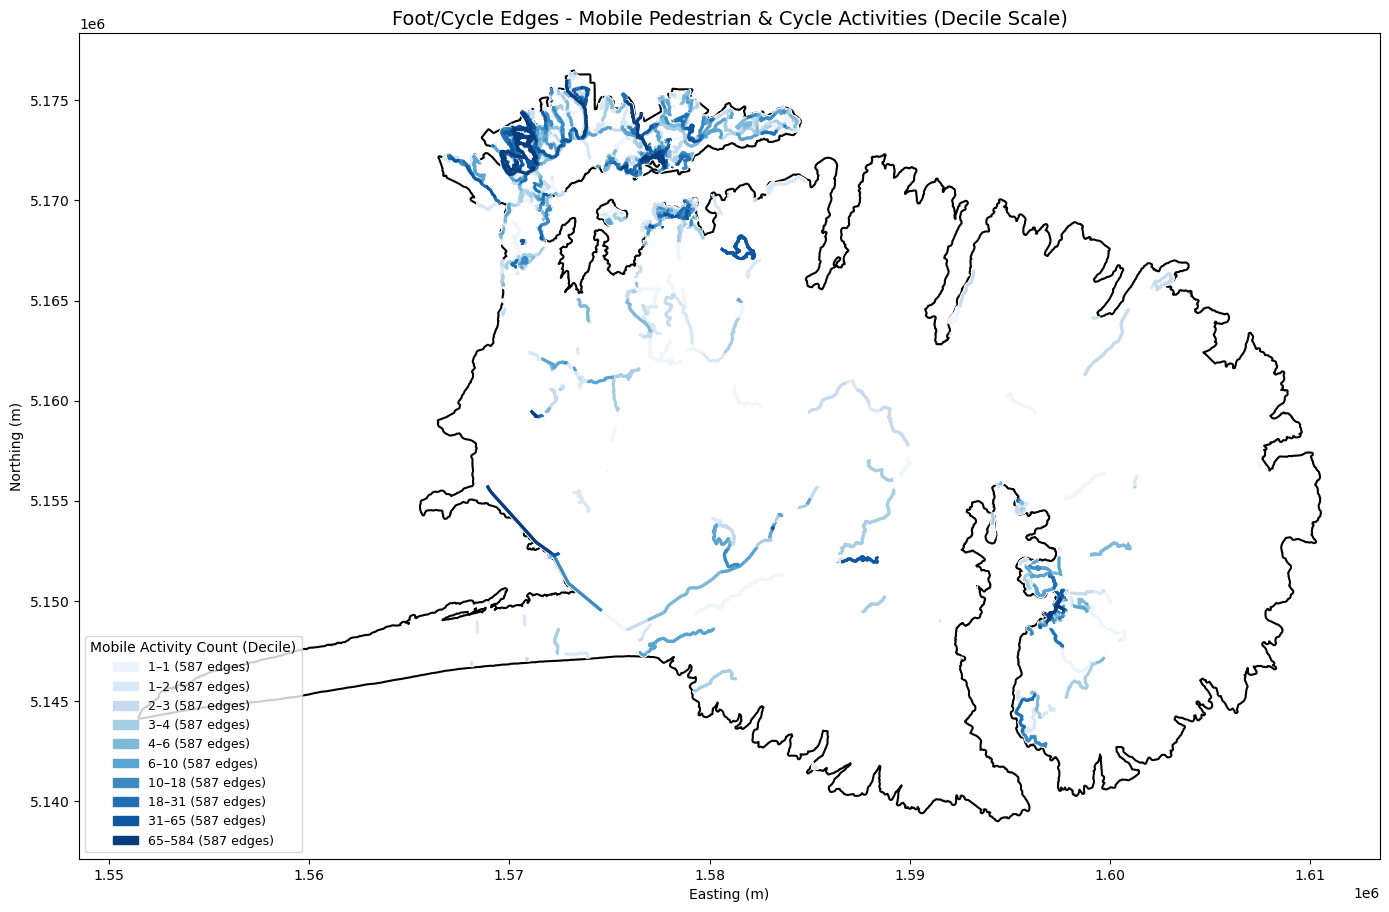

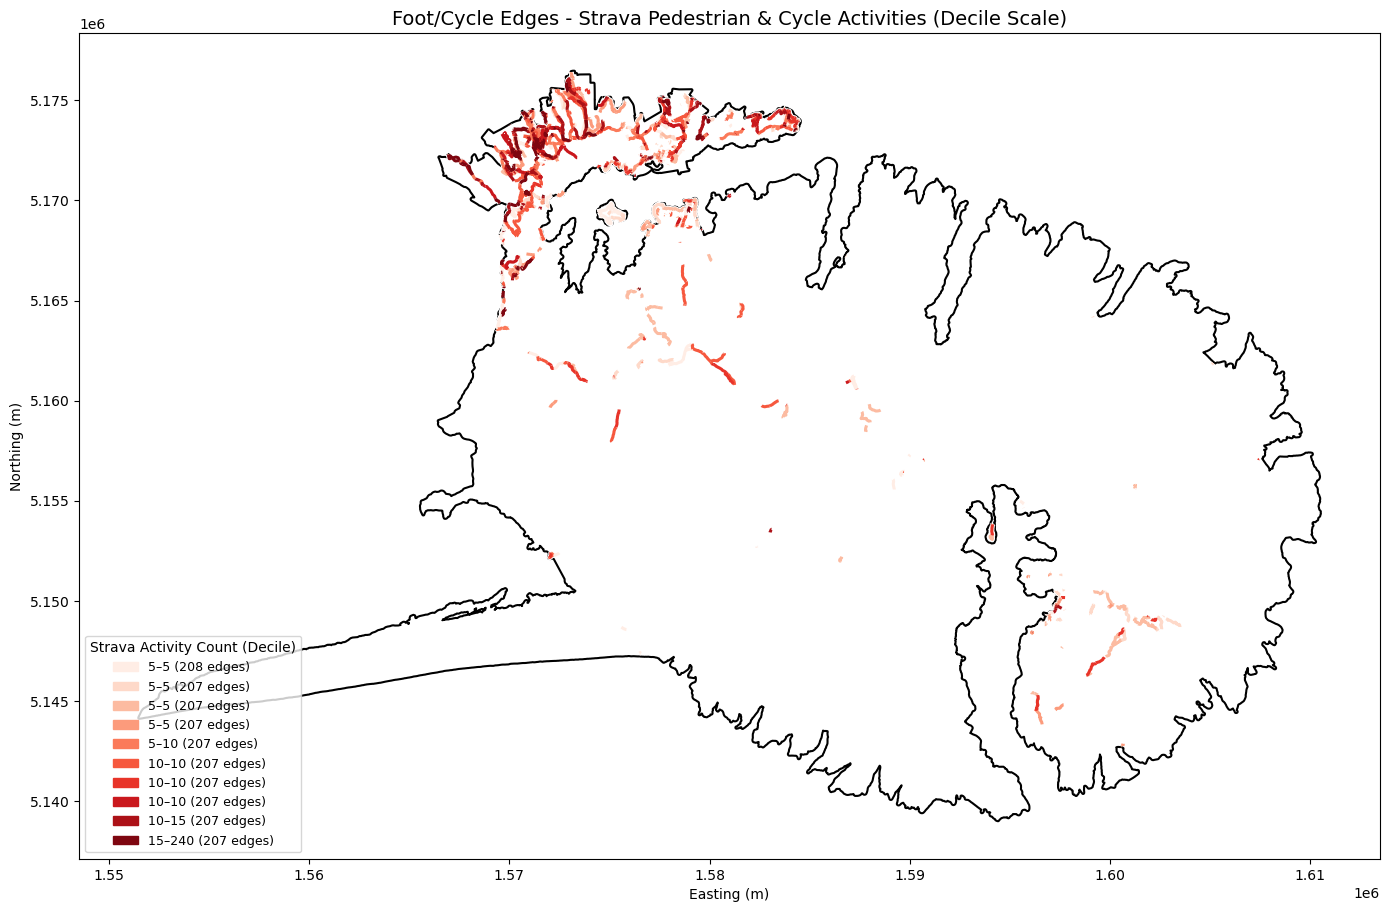

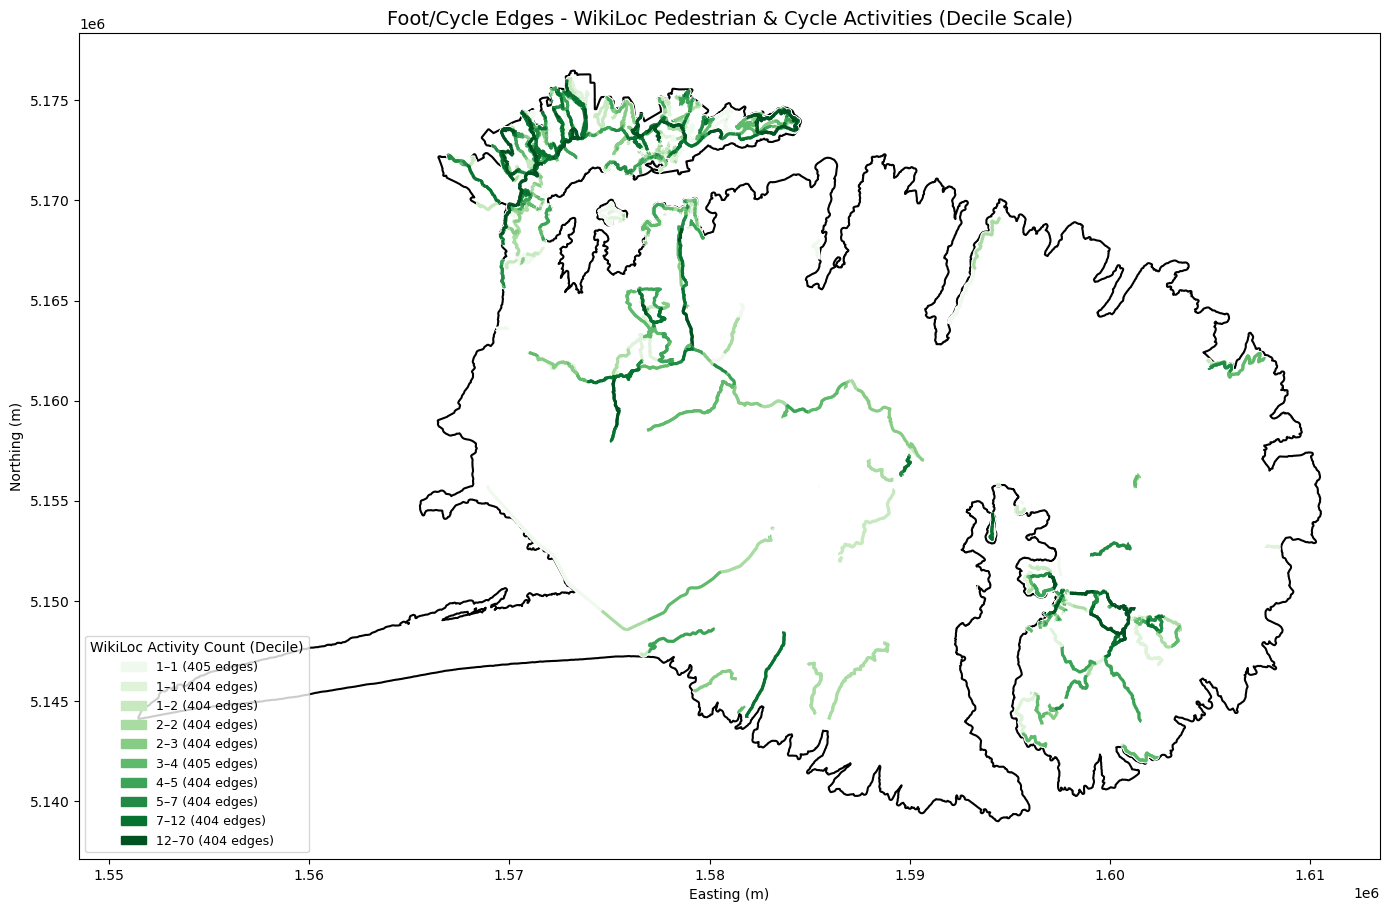

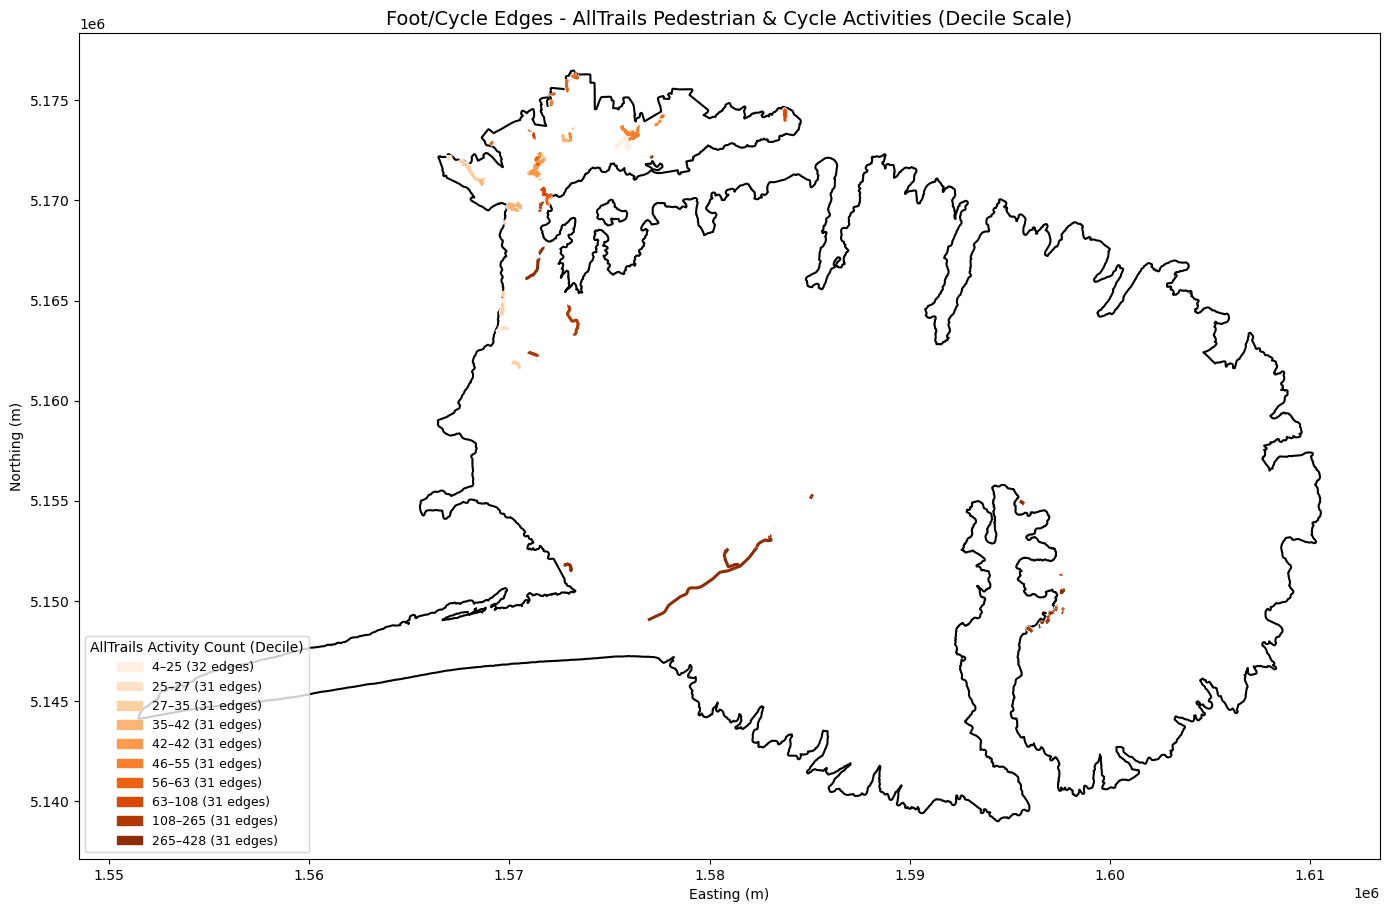

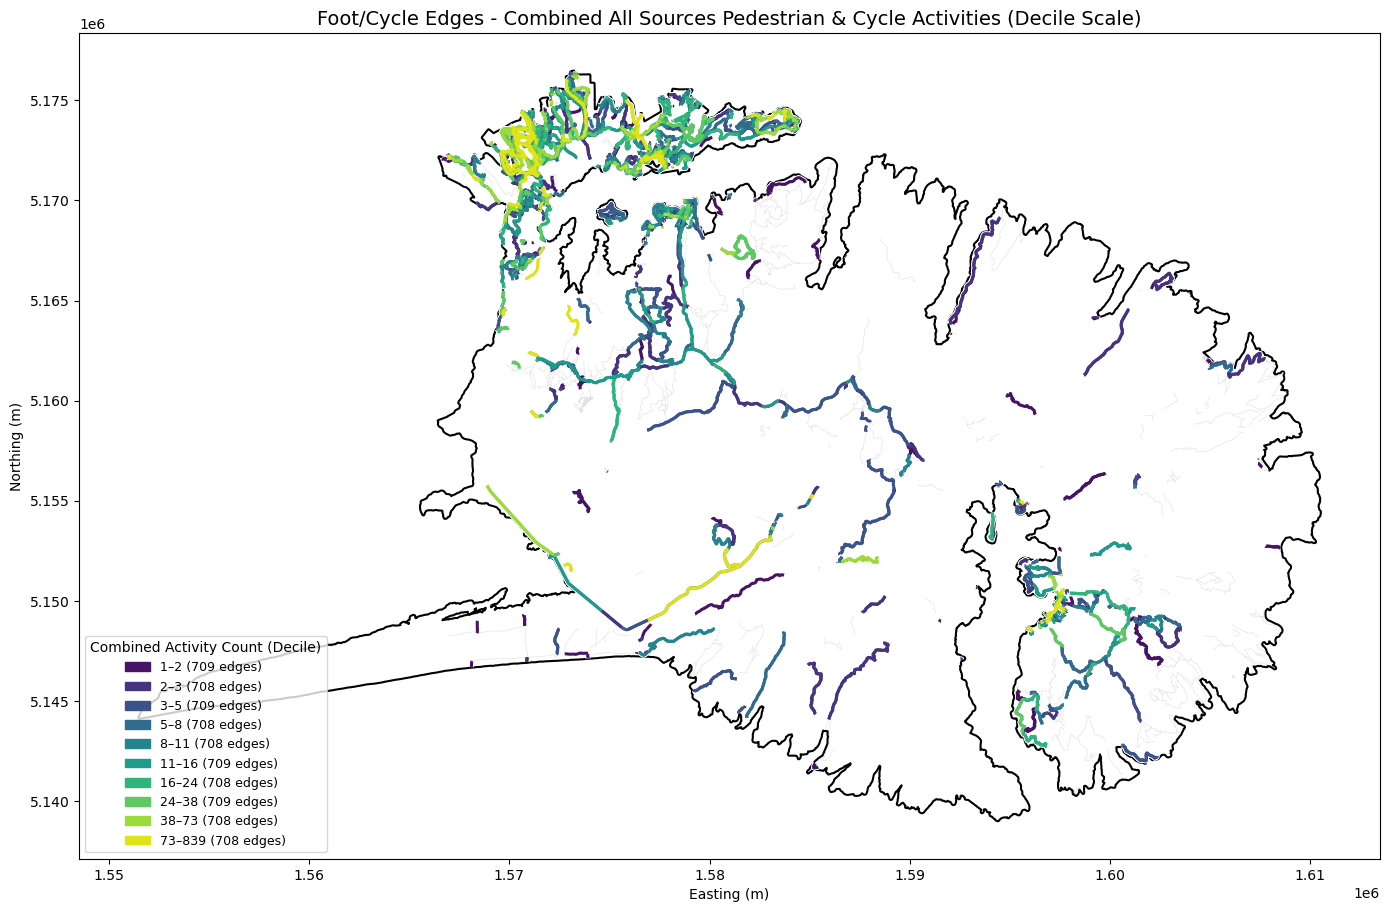

In [28]:
plot_edge_heatmap(
    mobile_edge_counts,
    "Foot/Cycle Edges - Mobile Pedestrian & Cycle Activities (Decile Scale)",
    "Blues",
    "Mobile Activity Count (Decile)",
)

plot_edge_heatmap(
    strava_edge_counts,
    "Foot/Cycle Edges - Strava Pedestrian & Cycle Activities (Decile Scale)",
    "Reds",
    "Strava Activity Count (Decile)",
)

plot_edge_heatmap(
    wikiloc_edge_counts,
    "Foot/Cycle Edges - WikiLoc Pedestrian & Cycle Activities (Decile Scale)",
    "Greens",
    "WikiLoc Activity Count (Decile)",
)

plot_edge_heatmap(
    alltrails_edge_counts,
    "Foot/Cycle Edges - AllTrails Pedestrian & Cycle Activities (Decile Scale)",
    "Oranges",
    "AllTrails Activity Count (Decile)",
)

# walking_mobile_edge_counts = build_mode_edge_counts(mobile_matched, "edge_ids", "pedestrian")
# walking_strava_edge_counts = build_mode_edge_counts(strava_matched, "edge_id", "pedestrian", weight_column="total_trip_count")
# walking_wikiloc_edge_counts = build_mode_edge_counts(wikiloc_matched, "edge_ids", "pedestrian")
# walking_alltrails_edge_counts = build_mode_edge_counts(alltrails_matched, "edge_ids", "pedestrian", weight_column="activity_pedestrian_count")

# cycling_mobile_edge_counts = build_mode_edge_counts(mobile_matched, "edge_ids", "cycle")
# cycling_strava_edge_counts = build_mode_edge_counts(strava_matched, "edge_id", "cycle", weight_column="total_trip_count")
# cycling_wikiloc_edge_counts = build_mode_edge_counts(wikiloc_matched, "edge_ids", "cycle")
# cycling_alltrails_edge_counts = build_mode_edge_counts(alltrails_matched, "edge_ids", "cycle", weight_column="activity_cycle_count")

# walking_edge_counts = {
#     edge_idx: walking_mobile_edge_counts.get(edge_idx, 0)
#     + walking_strava_edge_counts.get(edge_idx, 0)
#     + walking_wikiloc_edge_counts.get(edge_idx, 0)
#     + walking_alltrails_edge_counts.get(edge_idx, 0)
#     for edge_idx in edges_filtered.index
# }

# cycling_edge_counts = {
#     edge_idx: cycling_mobile_edge_counts.get(edge_idx, 0)
#     + cycling_strava_edge_counts.get(edge_idx, 0)
#     + cycling_wikiloc_edge_counts.get(edge_idx, 0)
#     + cycling_alltrails_edge_counts.get(edge_idx, 0)
#     for edge_idx in edges_filtered.index
# }

combined_edge_counts = {
    edge_idx: mobile_edge_counts.get(edge_idx, 0)
    + strava_edge_counts.get(edge_idx, 0)
    + wikiloc_edge_counts.get(edge_idx, 0)
    + alltrails_edge_counts.get(edge_idx, 0)
    for edge_idx in edges_filtered.index
}

# plot_edge_heatmap(
#     walking_edge_counts,
#     "Foot/Cycle Edges - Walking Activities Across All Sources (Decile Scale)",
#     "Greens",
#     "Walking Activity Count (Decile)",
# )

# plot_edge_heatmap(
#     cycling_edge_counts,
#     "Foot/Cycle Edges - Cycling Activities Across All Sources (Decile Scale)",
#     "Oranges",
#     "Cycling Activity Count (Decile)",
# )

plot_edge_heatmap(
    combined_edge_counts,
    "Foot/Cycle Edges - Combined All Sources Pedestrian & Cycle Activities (Decile Scale)",
    "viridis",
    "Combined Activity Count (Decile)",
)

In [ ]:
import os

export_path = os.path.join('Data', 'edge_counts_by_source.gpkg')

edge_export = edges_filtered.copy()
edge_export['edge_id'] = edge_export.index

def series_from_counts(counts_dict):
    return pd.Series(counts_dict).reindex(edge_export.index, fill_value=0).astype(int)

source_mode_counts = {
    'mobile': {
        'pedestrian': series_from_counts(walking_mobile_edge_counts),
        'cycle': series_from_counts(cycling_mobile_edge_counts),
    },
    'strava': {
        'pedestrian': series_from_counts(walking_strava_edge_counts),
        'cycle': series_from_counts(cycling_strava_edge_counts),
    },
    'wikiloc': {
        'pedestrian': series_from_counts(walking_wikiloc_edge_counts),
        'cycle': series_from_counts(cycling_wikiloc_edge_counts),
    },
    'alltrails': {
        'pedestrian': series_from_counts(walking_alltrails_edge_counts),
        'cycle': series_from_counts(cycling_alltrails_edge_counts),
    },
}

for source_name, mode_counts in source_mode_counts.items():
    edge_export[f'{source_name}_pedestrian_count'] = mode_counts['pedestrian']
    edge_export[f'{source_name}_cycle_count'] = mode_counts['cycle']
    edge_export[f'{source_name}_total_count'] = mode_counts['pedestrian'] + mode_counts['cycle']

edge_export['total_pedestrian_count'] = sum(mode_counts['pedestrian'] for mode_counts in (
    source_mode_counts['mobile'],
    source_mode_counts['strava'],
    source_mode_counts['wikiloc'],
    source_mode_counts['alltrails'],
))
edge_export['total_cycle_count'] = sum(mode_counts['cycle'] for mode_counts in (
    source_mode_counts['mobile'],
    source_mode_counts['strava'],
    source_mode_counts['wikiloc'],
    source_mode_counts['alltrails'],
))
edge_export['total_count'] = edge_export['total_pedestrian_count'] + edge_export['total_cycle_count']


edge_export.drop(columns=[col for col in edge_export.columns if col not in [
    'edge_id',
    'fid_1','name','osmid', 'highway','RDBPT_Sub', 'RDBPT_Num', 'mobile_pedestrian_count','mobile_cycle_count', 'mobile_total_count',
    'strava_pedestrian_count', 'strava_cycle_count', 'strava_total_count',
    'wikiloc_pedestrian_count', 'wikiloc_cycle_count', 'wikiloc_total_count',
    'alltrails_pedestrian_count', 'alltrails_cycle_count', 'alltrails_total_count',
    'total_pedestrian_count', 'total_cycle_count', 'total_count','geometry'
]], inplace=True)
edge_export.to_file(export_path, driver='GPKG')
print(f'Saved edge export to {export_path}')
print(edge_export[[
    'edge_id',
    'mobile_pedestrian_count', 'mobile_cycle_count', 'mobile_total_count',
    'strava_pedestrian_count', 'strava_cycle_count', 'strava_total_count',
    'wikiloc_pedestrian_count', 'wikiloc_cycle_count', 'wikiloc_total_count',
    'alltrails_pedestrian_count', 'alltrails_cycle_count', 'alltrails_total_count',
    'total_pedestrian_count', 'total_cycle_count', 'total_count',
 ]].head())

Saved edge export to Data\edge_counts_by_source.gpkg
    edge_id  mobile_pedestrian_count  mobile_cycle_count  mobile_total_count  \
3         3                      435                   0                 435   
12       12                      135                   0                 135   
16       16                      489                   0                 489   
17       17                       89                   0                  89   
18       18                       33                   0                  33   

    strava_pedestrian_count  strava_cycle_count  strava_total_count  \
3                         0                   0                   0   
12                        0                   0                   0   
16                        0                   0                   0   
17                        0                   0                   0   
18                       80                   0                  80   

    wikiloc_pedestrian_count  wikiloc_c

# Te Ara Analysis

In [ ]:
edge_counts = gpd.read_file("Data\\/edge_counts_by_source.gpkg")


<Axes: >

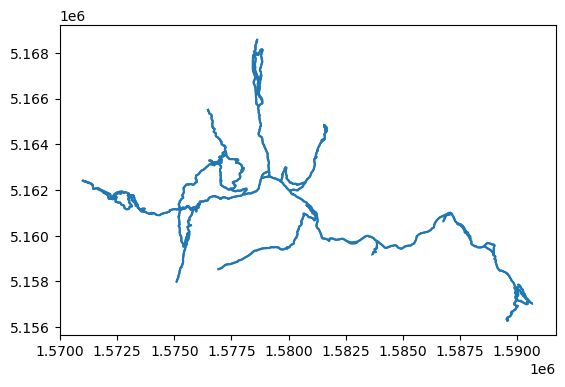

In [ ]:
Te_Ara_edges = edge_counts.query("RDBPT_Sub == 'TeAra' and RDBPT_Num.notna()").copy()
Te_Ara_edges.plot()

In [ ]:
source_prefixes = ['mobile', 'strava', 'wikiloc', 'alltrails']

def build_te_ara_table(edges_df):
    table = edges_df.copy()

    for source_name in source_prefixes:
        total_col = f'{source_name}_total_count'
        ped_col = f'{source_name}_pedestrian_count'
        cycle_col = f'{source_name}_cycle_count'

        if total_col not in table.columns:
            ped_series = table[ped_col] if ped_col in table.columns else 0
            cycle_series = table[cycle_col] if cycle_col in table.columns else 0
            table[total_col] = ped_series + cycle_series

    source_total_cols = [f'{source_name}_total_count' for source_name in source_prefixes if f'{source_name}_total_count' in table.columns]

    grouped = (
        table.groupby('RDBPT_Num', as_index=False)[source_total_cols]
        .sum()
        .sort_values(['RDBPT_Num'])
        .reset_index(drop=True)
    )

    grouped['total_count'] = grouped[source_total_cols].sum(axis=1)
    grouped = grouped.sort_values(['total_count', 'RDBPT_Num'], ascending=[False, True]).reset_index(drop=True)
    grouped.insert(0, 'rank', range(1, len(grouped) + 1))
    return grouped

te_ara_table = build_te_ara_table(Te_Ara_edges)

display_cols = [
    'rank',
    'RDBPT_Num',
    'mobile_total_count',
    'strava_total_count',
    'wikiloc_total_count',
    'alltrails_total_count',
    'total_count',
]

styled_te_ara_table = (
    te_ara_table[display_cols]
    .style
    .format({
        'mobile_total_count': '{:,.0f}',
        'strava_total_count': '{:,.0f}',
        'wikiloc_total_count': '{:,.0f}',
        'alltrails_total_count': '{:,.0f}',
        'total_count': '{:,.0f}',
    })
    .background_gradient(subset=['mobile_total_count'], cmap='Blues')
    .background_gradient(subset=['strava_total_count'], cmap='Reds')
    .background_gradient(subset=['wikiloc_total_count'], cmap='Greens')
    .background_gradient(subset=['alltrails_total_count'], cmap='Oranges')
    .background_gradient(subset=['total_count'], cmap='viridis')
    .set_caption('Te Ara edges grouped by RDBPT number with summed source totals')
)

display(styled_te_ara_table)

,rank,RDBPT_Num,mobile_total_count,strava_total_count,wikiloc_total_count,alltrails_total_count,total_count
0,1,1,98,"52,200",125,"14,909","67,332"
1,2,12,16,"56,640",188,"6,856","63,700"
2,3,2,8,"15,530",217,"2,424","18,179"
3,4,11,11,"4,820",186,"8,019","13,036"
4,5,5,25,"5,570",75,"2,781","8,451"
5,6,3,5,"6,550",48,"1,417","8,020"
6,7,7,3,"1,160",120,"5,905","7,188"
7,8,8,13,"1,500",171,"4,158","5,842"
8,9,14,11,600,18,"1,248","1,877"
9,10,10,8,"1,190",50,0,"1,248"


In [ ]:
import ast

def to_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    text = str(value)
    if text.startswith('[') and text.endswith(']'):
        try:
            return ast.literal_eval(text)
        except Exception:
            return [value]
    return [value]

def normalize_edge_lookup(edge_counts):
    lookup = edge_counts[['edge_id', 'RDBPT_Num']].copy()
    lookup['edge_key'] = pd.to_numeric(lookup['edge_id'], errors='coerce').astype('Int64')
    lookup = lookup.dropna(subset=['edge_key']).copy()
    lookup['edge_key'] = lookup['edge_key'].astype(int).astype(str)
    return lookup.set_index('edge_key')['RDBPT_Num']

def first_existing_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None

def build_source_te_ara_counts(matched_df, edge_lookup, edge_col_candidates, weight_cols=None, activity_col_candidates=None):
    table = matched_df.copy()
    if activity_col_candidates is None:
        activity_col_candidates = ['activity_id', 'trip_id', 'trajectory_id', 'id']
    activity_col = first_existing_column(table, activity_col_candidates)
    if activity_col is None:
        activity_col = next((col for col in table.columns if 'activity' in col.lower() and 'id' in col.lower()), None)
    if activity_col is None:
        raise KeyError(f'Could not find an activity id column in {list(table.columns)}')

    edge_col = first_existing_column(table, edge_col_candidates)
    if edge_col is None:
        raise KeyError(f'Could not find an edge column in {list(table.columns)}')

    selected_columns = [activity_col, edge_col]
    if weight_cols:
        selected_columns.extend([col for col in weight_cols if col in table.columns])
    table = table[selected_columns].copy()
    table['edge_id_list'] = table[edge_col].apply(to_list)
    table = table.explode('edge_id_list')
    table['edge_id'] = pd.to_numeric(table['edge_id_list'], errors='coerce')
    table = table.dropna(subset=['edge_id']).copy()
    table['edge_id'] = table['edge_id'].astype(int)
    table['edge_key'] = table['edge_id'].astype(str)
    table['RDBPT_Num'] = table['edge_key'].map(edge_lookup)
    table['RDBPT_Num'] = pd.to_numeric(table['RDBPT_Num'], errors='coerce').astype('Int64')
    table = table[table['RDBPT_Num'].notna()].copy()

    if weight_cols:
        active_weight_cols = [col for col in weight_cols if col in table.columns]
        if len(active_weight_cols) > 1:
            table['activity_total_count'] = table[active_weight_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
            weight_col = 'activity_total_count'
        elif len(active_weight_cols) == 1:
            weight_col = active_weight_cols[0]
        else:
            weight_col = None
    else:
        weight_col = None

    if weight_col is not None:
        deduped = table[['RDBPT_Num', activity_col, weight_col]].drop_duplicates()
        deduped[weight_col] = pd.to_numeric(deduped[weight_col], errors='coerce').fillna(0)
        counts = deduped.groupby('RDBPT_Num')[weight_col].sum()
    else:
        counts = table.groupby('RDBPT_Num')[activity_col].nunique()

    return counts

edge_lookup = normalize_edge_lookup(edge_counts)
rdbpt_base = pd.DataFrame({'RDBPT_Num': pd.to_numeric(Te_Ara_edges['RDBPT_Num'], errors='coerce').dropna().astype(int).sort_values().unique()})
rdbpt_base['RDBPT_Num'] = rdbpt_base['RDBPT_Num'].astype('Int64')

source_counts = {
    'mobile': build_source_te_ara_counts(Mobile_activities, edge_lookup, ['edge_ids']),
    'strava': build_source_te_ara_counts(strava_matched, edge_lookup, ['edge_id'], weight_cols=['total_trip_count'], activity_col_candidates=['edge_uid', 'activity_id', 'trip_id', 'trajectory_id', 'id']),
    'wikiloc': build_source_te_ara_counts(wikiloc_matched, edge_lookup, ['edge_ids']),
    'alltrails': build_source_te_ara_counts(alltrails_matched, edge_lookup, ['edge_ids'], weight_cols=['activity_pedestrian_count', 'activity_cycle_count']),
}

te_ara_table = rdbpt_base.copy()
for source_name, counts in source_counts.items():
    te_ara_table = te_ara_table.merge(counts.rename(f'{source_name}_total_count'), on='RDBPT_Num', how='left')

te_ara_table = te_ara_table.fillna(0)
for source_name in source_counts:
    te_ara_table[f'{source_name}_total_count'] = te_ara_table[f'{source_name}_total_count'].astype(int)
te_ara_table['total_count'] = te_ara_table[[f'{source_name}_total_count' for source_name in source_counts]].sum(axis=1).astype(int)
te_ara_table = te_ara_table.sort_values(['total_count', 'RDBPT_Num'], ascending=[False, True]).reset_index(drop=True)
te_ara_table.insert(0, 'rank', range(1, len(te_ara_table) + 1))

display_cols = [
    'rank',
    'RDBPT_Num',
    'mobile_total_count',
    'strava_total_count',
    'wikiloc_total_count',
    'alltrails_total_count',
    'total_count',
]

styled_te_ara_table = (
    te_ara_table[display_cols]
    .style
    .format({
        'mobile_total_count': '{:,.0f}',
        'strava_total_count': '{:,.0f}',
        'wikiloc_total_count': '{:,.0f}',
        'alltrails_total_count': '{:,.0f}',
        'total_count': '{:,.0f}',
    })
    .background_gradient(subset=['mobile_total_count'], cmap='Blues')
    .background_gradient(subset=['strava_total_count'], cmap='Reds')
    .background_gradient(subset=['wikiloc_total_count'], cmap='Greens')
    .background_gradient(subset=['alltrails_total_count'], cmap='Oranges')
    .background_gradient(subset=['total_count'], cmap='viridis')
    .set_caption('Te Ara edges grouped by RDBPT number with summed source totals')
)

display(styled_te_ara_table)

,rank,RDBPT_Num,mobile_total_count,strava_total_count,wikiloc_total_count,alltrails_total_count,total_count
0,1,1,49,"1,820",16,451,"2,336"
1,2,12,6,885,48,523,"1,462"
2,3,2,5,905,27,261,"1,198"
3,4,11,8,325,27,625,985
4,5,5,8,300,13,125,446
5,6,3,3,155,15,257,430
6,7,8,5,40,24,313,382
7,8,7,3,30,13,195,241
8,9,10,4,190,5,0,199
9,10,14,6,40,2,96,144


# Legacy